# 📘 Lecture 9: Transformations of Random Variables, MGFs, Convolution, Central Limit Theorem & Monte Carlo
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 9 - YouTube](https://youtu.be/p6PMCWIMLqE?si=7CI49gmJtPGeEaXm)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we explore key operational principles for manipulating continuous and discrete random variables:
1. **Transformations of Random Variables**: Discrete mapping $P(Y=y) = \sum_{f(x)=y} P(X=x)$, continuous scalar change of variables $p_Y(y) = p_X(g(y)) |\frac{dx}{dy}|$, and multivariate Jacobian determinant $|\text{det} \mathbf{J}|$ (Cartesian to Polar coordinates $|\text{det} \mathbf{J}| = r$).
2. **Moments of Affine Transformations**: Vector map $\mathbf{Y} = \mathbf{A}\mathbf{X} + \mathbf{b}$ leading to $\mathbb{E}[\mathbf{Y}] = \mathbf{A}\boldsymbol{\mu} + \mathbf{b}$ and covariance matrix $\text{Cov}(\mathbf{Y}) = \mathbf{A} \boldsymbol{\Sigma}_X \mathbf{A}^\top$.
3. **Convolution Theorem**: Proving that the PDF of the sum of two independent continuous random variables $Y = X_1 + X_2$ is given by convolution $p_Y(y) = (p_{X_1} * p_{X_2})(y)$.
4. **Moment Generating Functions (MGF)**: Defining $M_X(t) = \mathbb{E}[e^{tX}]$, proving $M_X(t) = \exp(\mu t + \frac{1}{2}\sigma^2 t^2)$ for Gaussians by completing the square, and proving closure under addition.
5. **Central Limit Theorem (CLT)**: Demonstrating how the standardized sample mean $Z_N = \frac{\bar{X}_N - \mu}{\sigma / \sqrt{N}}$ converges to $\mathcal{N}(0, 1)$ as $N \to \infty$ regardless of the underlying distribution (e.g. highly skewed Beta).
6. **Monte Carlo Approximation**: Handling non-invertible transformations ($Y = X^2$) via empirical Dirac impulse sampling $\hat{P}_Y(y) = \frac{1}{N_s} \sum \delta(y - y^{(s)})$.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, statistics, and visualization packages.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Transformations of Random Variables & Jacobian Determinant

### 1.1 Discrete & Continuous Scalar Change of Variables
- **Discrete Case**: $P(Y = y) = \sum_{x: f(x) = y} P(X = x)$
- **Continuous Scalar Case**: Conservation of probability mass $|p_Y(y) dy| = |p_X(x) dx|$ yields:
  $$p_Y(y) = p_X(g(y)) \left| \frac{dx}{dy} \right| = p_X(f^{-1}(y)) \left| \frac{d}{dy} f^{-1}(y) \right|$$

### 1.2 Multivariate Change of Variables & Jacobian Matrix
For $\mathbf{y} = f(\mathbf{x}) \in \mathbb{R}^D$ with inverse $\mathbf{x} = g(\mathbf{y})$:
$$p_\mathbf{Y}(\mathbf{y}) = p_\mathbf{X}(g(\mathbf{y})) \left| \text{det} \mathbf{J}_g(\mathbf{y}) \right|, \quad \mathbf{J}_g(\mathbf{y}) = \frac{\partial g(\mathbf{y})}{\partial \mathbf{y}^\top} \in \mathbb{R}^{D \times D}$$

#### Cartesian to Polar Transformation Example:
$x_1 = r \cos \theta, \quad x_2 = r \sin \theta$
$$\mathbf{J} = \begin{bmatrix} \frac{\partial x_1}{\partial r} & \frac{\partial x_1}{\partial \theta} \\ \frac{\partial x_2}{\partial r} & \frac{\partial x_2}{\partial \theta} \end{bmatrix} = \begin{bmatrix} \cos\theta & -r\sin\theta \\ \sin\theta & r\cos\theta \end{bmatrix} \implies |\text{det} \mathbf{J}| = r (\cos^2\theta + \sin^2\theta) = r$$
$$p_{R, \Theta}(r, \theta) = p_{X_1, X_2}(r\cos\theta, r\sin\theta) \cdot r \implies dA = r \, dr \, d\theta$$


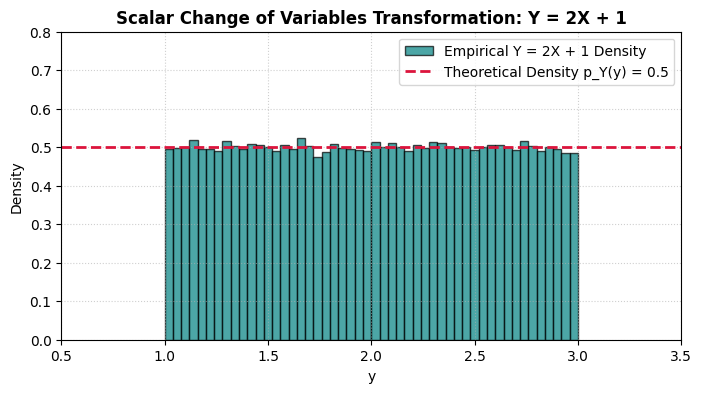

In [2]:
# Code Verification of Scalar Change of Variables: Linear Scaling Y = 2X + 1
# X ~ Unif(0, 1) -> p_X(x) = 1 for x in [0, 1]
# Y = 2X + 1 -> Inverse g(y) = (y - 1)/2, |dx/dy| = 1/2
# Expected p_Y(y) = 1 * (1/2) = 0.5 for y in [1, 3]

#Start code here..
#Number of samples for our monte carlo simulation
N_samples = 100000
#Generate samples from a uniform distribution
x_samples = np.random.uniform(0,1,N_samples)
y_samples = 2*x_samples + 1

#End code here..
plt.figure(figsize=(8, 4))
plt.hist(y_samples, bins=50, density=True, color='teal', alpha=0.7, edgecolor='black', label='Empirical Y = 2X + 1 Density')
plt.axhline(0.5, color='crimson', linestyle='--', linewidth=2, label='Theoretical Density p_Y(y) = 0.5')
plt.xlim(0.5, 3.5)
plt.ylim(0, 0.8)
plt.xlabel('y')
plt.ylabel('Density')
plt.title('Scalar Change of Variables Transformation: Y = 2X + 1', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 2️⃣ Moments of Affine Transformations & Covariance

### 2.1 Vector Affine Transformation
Let $\mathbf{Y} = \mathbf{A}\mathbf{X} + \mathbf{b}$ where $\mathbf{X} \in \mathbb{R}^D$ has mean $\boldsymbol{\mu}_X$ and covariance $\boldsymbol{\Sigma}_X$:
1. **Expectation**: $\mathbb{E}[\mathbf{Y}] = \mathbf{A} \mathbb{E}[\mathbf{X}] + \mathbf{b} = \mathbf{A} \boldsymbol{\mu}_X + \mathbf{b}$
2. **Covariance Matrix**:
   $$\text{Cov}(\mathbf{Y}) = \mathbb{E}[(\mathbf{Y} - \boldsymbol{\mu}_Y)(\mathbf{Y} - \boldsymbol{\mu}_Y)^\top] = \mathbb{E}[\mathbf{A}(\mathbf{X} - \boldsymbol{\mu}_X)(\mathbf{X} - \boldsymbol{\mu}_X)^\top \mathbf{A}^\top] = \mathbf{A} \boldsymbol{\Sigma}_X \mathbf{A}^\top$$

### 2.2 Sum of Two Random Variables
For $Y = a_1 X_1 + a_2 X_2$:
$$\text{Var}(Y) = a_1^2 \text{Var}(X_1) + a_2^2 \text{Var}(X_2) + 2 a_1 a_2 \text{Cov}(X_1, X_2)$$


In [3]:
#Start code here..
#This section verifies the formula for the covariance of an affine transformation
#Mean vector and covariance for X
mu_X = np.array([1.0,2.0])
Sigma_X = np.array([[2.0,0.8],[0.8, 1.5]])

#Defining a transformation matrix A, and bias vector b for Y=AX+b
A_mat = np.array([[1.5,-0.5],[0.5,2.0]])
b_vec = np.array([0.5,-1.0])

#Calculate the theoretical mean and covariance for Y using the formula
theo_mu_Y = A_mat @ mu_X + b_vec
theo_Sigma_Y = A_mat @ Sigma_X @ A_mat.T

#Empirical sampling verification: Generate many samples of X, and transform then into Y
X_sim = np.random.multivariate_normal(mu_X, Sigma_X, size=100000)
Y_sim = (A_mat @ X_sim.T).T + b_vec #we apply the affine transformation

#We calculate the empirical mean and covariance from the simulated Y samples
emp_mu_Y = np.mean(Y_sim, axis=0)
emp_Sigma_Y = np.cov(Y_sim, rowvar=False)

#End code here..
print("📊 Affine Moment Transformation Verification:")
print(f"   Theoretical Mean E[Y]: {theo_mu_Y} | Empirical: {emp_mu_Y.round(4)}")
print("   Theoretical Covariance Cov(Y) = A * Sigma_X * A^T:")
print(theo_Sigma_Y)
print("   Empirical Covariance:")
print(emp_Sigma_Y.round(4))


📊 Affine Moment Transformation Verification:
   Theoretical Mean E[Y]: [1.  3.5] | Empirical: [1.     3.4917]
   Theoretical Covariance Cov(Y) = A * Sigma_X * A^T:
[[3.675 2.2  ]
 [2.2   8.1  ]]
   Empirical Covariance:
[[3.6812 2.1979]
 [2.1979 8.0672]]


## 3️⃣ Convolution Theorem for Sums of Independent Random Variables

### 3.1 Mathematical Derivation
Let $Y = X_1 + X_2$ where $X_1 \perp X_2$ are independent continuous random variables.
The Cumulative Distribution Function (CDF) of $Y$ is:
$$F_Y(y) = P(X_1 + X_2 \le y) = \int_{-\infty}^{\infty} p_{X_1}(x_1) \left[ \int_{-\infty}^{y - x_1} p_{X_2}(x_2) dx_2 \right] dx_1$$

Differentiating $F_Y(y)$ with respect to $y$ using **Leibniz's Rule** yields the **Convolution Theorem**:
$$p_Y(y) = (p_{X_1} * p_{X_2})(y) = \int_{-\infty}^{\infty} p_{X_1}(x) p_{X_2}(y - x) dx$$


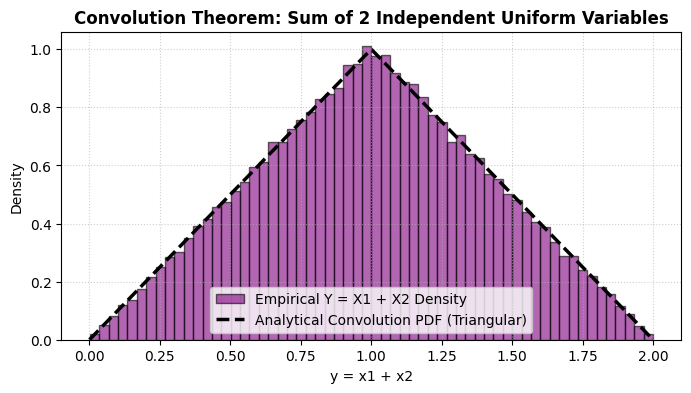

In [5]:
#Start code here..
N_conv = 100000
x1_samples = np.random.uniform(0, 1, N_conv)
x2_samples = np.random.uniform(0, 1, N_conv)
y_sum_samples = x1_samples + x2_samples

y_grid = np.linspace(0,2,500)
triangular_pdf = np.where(y_grid <= 1.0 , y_grid, 2.0 - y_grid)



#End code here..
plt.figure(figsize=(8, 4))
plt.hist(y_sum_samples, bins=60, density=True, color='purple', alpha=0.6, edgecolor='black', label='Empirical Y = X1 + X2 Density')
plt.plot(y_grid, triangular_pdf, color='black', linewidth=2.5, linestyle='--', label='Analytical Convolution PDF (Triangular)')
plt.xlabel('y = x1 + x2')
plt.ylabel('Density')
plt.title('Convolution Theorem: Sum of 2 Independent Uniform Variables', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 4️⃣ Moment Generating Functions (MGF) & Gaussian Closure Proof

### 4.1 Definition & Moment Generation
The Moment Generating Function (MGF) of $X$ is defined as:
$$M_X(t) = \mathbb{E}[e^{tX}] = \int_{-\infty}^{\infty} e^{tx} p_X(x) dx$$

Expanding $e^{tX}$ via Taylor Series:
$$M_X(t) = \mathbb{E}\left[ 1 + tX + \frac{t^2 X^2}{2!} + \frac{t^3 X^3}{3!} + \dots \right] = 1 + t \mathbb{E}[X] + \frac{t^2}{2!} \mathbb{E}[X^2] + \dots \implies \mathbb{E}[X^k] = \left. \frac{d^k}{dt^k} M_X(t) \right|_{t=0}$$

### 4.2 Analytical Proof: MGF of Gaussian $\mathcal{N}(\mu, \sigma^2)$
$$\mathbb{E}[e^{tX}] = \frac{1}{\sqrt{2\pi\sigma^2}} \int_{-\infty}^{\infty} \exp\left( tx - \frac{(x - \mu)^2}{2\sigma^2} \right) dx$$

Completing the square in the exponent:
$$tx - \frac{(x - \mu)^2}{2\sigma^2} = \mu t + \frac{1}{2}\sigma^2 t^2 - \frac{(x - (\mu + \sigma^2 t))^2}{2\sigma^2}$$

Factoring out terms independent of $x$:
$$M_X(t) = \exp\left( \mu t + \frac{1}{2}\sigma^2 t^2 \right) \underbrace{\frac{1}{\sqrt{2\pi\sigma^2}} \int_{-\infty}^{\infty} \exp\left( - \frac{(x - (\mu + \sigma^2 t))^2}{2\sigma^2} \right) dx}_{1} = \exp\left( \mu t + \frac{1}{2}\sigma^2 t^2 \right)$$

### 4.3 Proof: Sum of Independent Gaussians is Gaussian
Let $X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2)$ and $X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2)$ be independent. For $Y = X_1 + X_2$:
$$M_Y(t) = \mathbb{E}[e^{t(X_1 + X_2)}] = M_{X_1}(t) \cdot M_{X_2}(t) = \exp\left( \mu_1 t + \frac{1}{2}\sigma_1^2 t^2 \right) \exp\left( \mu_2 t + \frac{1}{2}\sigma_2^2 t^2 \right) = \exp\left( (\mu_1 + \mu_2) t + \frac{1}{2}(\sigma_1^2 + \sigma_2^2) t^2 \right)$$

By uniqueness of MGFs, $Y \sim \mathcal{N}(\mu_1 + \mu_2, \sigma_1^2 + \sigma_2^2)$.

In [6]:
#Start code here...
#Code verification of Moment Generating Function for Normal(mean=3, variance = 4)
mu_test, sigma_test = 3.0,2.0
t_eps = 1e-5
def mgf_norm(t):
    return np.exp(mu_test * t + 0.5 * (sigma_test**2) * (t**2))

#numerical first derivative
d1_M = (mgf_norm(t_eps) - mgf_norm(-t_eps))/ (2 * t_eps)
#numerical second derivative
d2_M = (mgf_norm(t_eps) - 2*mgf_norm(0) + mgf_norm(-t_eps))/(t_eps**2)


#End code here..

print("📊 MGF Moment Extraction Verification:")
print(f"   First Derivative M\'(0)  [E[X]]:   {d1_M:.4f}  (Theoretical: {mu_test:.1f})")
print(f"   Second Derivative M\"(0) [E[X^2]]: {d2_M:.4f}  (Theoretical: {mu_test**2 + sigma_test**2:.1f})")

#first derivative M'(0) = E[X] = mu = 3.0
#second derivate M''(0) = E[x^2] = E[X]^2 + Var(x) = 3^2 + 4 = 13


📊 MGF Moment Extraction Verification:
   First Derivative M'(0)  [E[X]]:   3.0000  (Theoretical: 3.0)
   Second Derivative M"(0) [E[X^2]]: 13.0000  (Theoretical: 13.0)


## 5️⃣ Central Limit Theorem (CLT) Simulation

### 5.1 Formal Statement
Let $X_1, X_2, \dots, X_N$ be i.i.d. random variables with mean $\mu$ and variance $\sigma^2$.
The sample mean $\bar{X}_N = \frac{1}{N} \sum_{i=1}^N X_i$ has standardized variable $Z_N$:
$$Z_N = \frac{\bar{X}_N - \mu}{\sigma / \sqrt{N}} = \frac{\sum_{i=1}^N X_i - N\mu}{\sigma \sqrt{N}} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{as } N \to \infty$$

Regardless of the underlying distribution $P(X)$ (even highly asymmetric or skewed distributions like $\text{Beta}(1, 5)$), the sampling distribution of the standardized mean converges to $\mathcal{N}(0, 1)$.

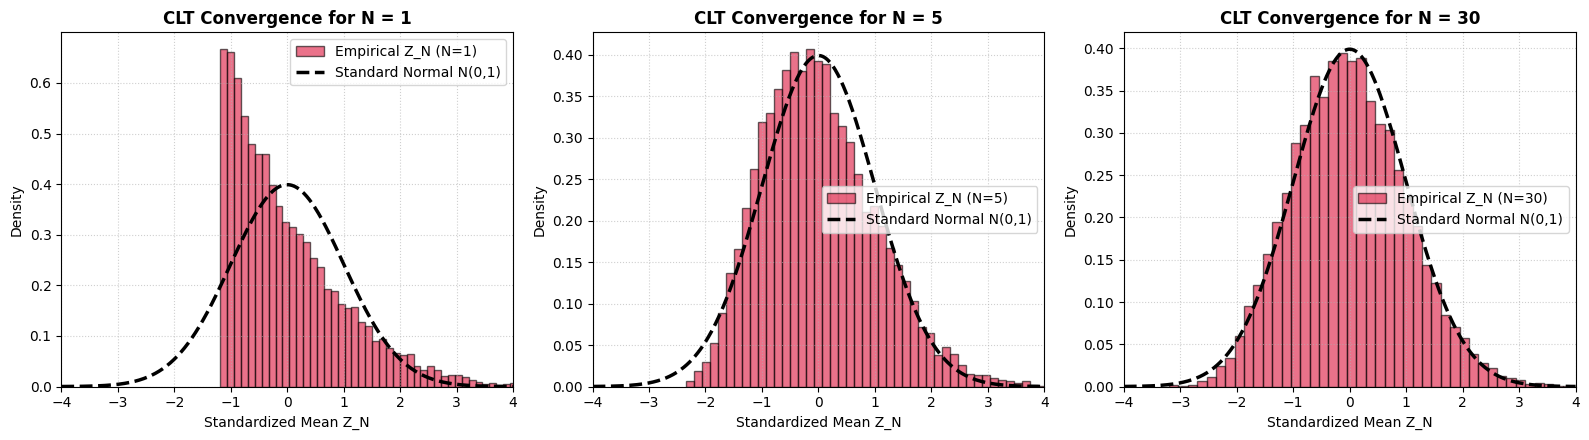

In [8]:
#Start code here...
#Simulation of Central limit theorem on highly skewed beta (1,5) distribution
#This simulation demonstrate that the sampling distribution of the mean approaches a normal distribution, even for a non-normal
#underyling distribution
a_param, b_param = 1.0, 5.0
#Calculate the theoretical mean and standard deviation of the beta distribution
true_mu = a_param / (a_param + b_param)
true_var = (a_param * b_param) / ((a_param + b_param)**2 * (a_param + b_param + 1))
true_std = np.sqrt(true_var)

N_experiments = 10000
sample_sizes = [1,5,30]

fig, axes = plt.subplots(1,3,figsize=(16,4.5))
grid_z = np.linspace(-4,4,500)
standard_norm_pdf = stats.norm.pdf(grid_z,0,1)

#End code here...

for idx, N in enumerate(sample_sizes):
    #Start code here...
    samples = np.random.beta(a_param, b_param, size=(N_experiments, N))
    sample_means = np.mean(samples, axis=1)
    Z_N  = (sample_means - true_mu) / (true_std / np.sqrt(N))
    #End code here..

    axes[idx].hist(Z_N, bins=50, density=True, color='crimson', alpha=0.6, edgecolor='black', label=f'Empirical Z_N (N={N})')
    axes[idx].plot(grid_z, standard_norm_pdf, color='black', linewidth=2.5, linestyle='--', label='Standard Normal N(0,1)')
    axes[idx].set_title(f'CLT Convergence for N = {N}', fontweight='bold')
    axes[idx].set_xlabel('Standardized Mean Z_N')
    axes[idx].set_ylabel('Density')
    axes[idx].set_xlim(-4, 4)
    axes[idx].legend()
    axes[idx].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 6️⃣ Monte Carlo Approximation for Non-Invertible Transformations

### 6.1 Non-Invertible Transformation Hazard
When a transformation $Y = f(X)$ is non-invertible (e.g. $Y = X^2$ where $X \sim \text{Unif}(-1, 1)$), the analytical change of variables formula fails or becomes tedious.

For $X \sim \text{Unif}(-1, 1)$, $Y = X^2 \in (0, 1)$, the exact analytical PDF is derived as:
$$p_Y(y) = \frac{1}{2\sqrt{y}}, \quad y \in (0, 1)$$

### 6.2 Monte Carlo Empirical Impulse Approximation
Using Monte Carlo sampling, we draw $N_s$ samples $x^{(s)} \sim P(X)$, compute $y^{(s)} = f(x^{(s)})$, and approximate $P_Y(y)$ empirically via Dirac impulses:
$$\hat{P}_Y(y) = \frac{1}{N_s} \sum_{s=1}^{N_s} \delta(y - y^{(s)})$


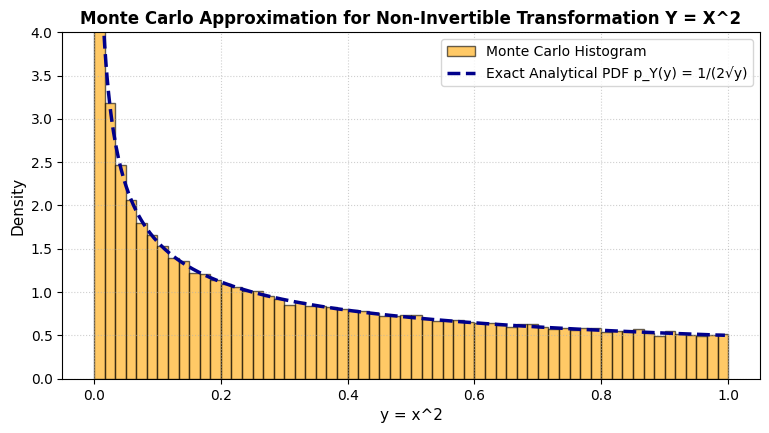

In [11]:
#Start code here..
N_mc = 100000
x_mc = np.random.uniform(-1,1,N_mc)
y_mc = x_mc**2

y_eval = np.linspace(0.005,0.995,500)
analytical_pdf_y = 1.0 / (2.0 * np.sqrt(y_eval))


#End code here...

plt.figure(figsize=(9, 4.5))
#plot the empirical histogram of Y samples from monte carlo
plt.hist(y_mc, bins=60, density=True, color='orange', alpha=0.6, edgecolor='black', label='Monte Carlo Histogram')
#Overlay the exact analytical PDF
plt.plot(y_eval, analytical_pdf_y, color='darkblue', linewidth=2.5, linestyle='--', label='Exact Analytical PDF p_Y(y) = 1/(2√y)')

plt.xlabel('y = x^2', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Monte Carlo Approximation for Non-Invertible Transformation Y = X^2', fontweight='bold')
plt.ylim(0, 4.0)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
